In [7]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm



In [8]:
df=pd.read_csv('CarPrice_Assignment.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [9]:
x=df[['enginesize','horsepower','citympg','highwaympg']]
y=df['price'] 
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [10]:
scalar=StandardScaler()
x_train_scaled=scalar.fit_transform(x_train)
x_test_scaled = scalar.transform(x_test)
model=LinearRegression()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)


In [11]:
print('Name:Branzen.B.V')
print('Reg. No:212225100005')
print("MODEL COEFFICIENTS:")
for feature, coef in zip(x.columns,model.coef_):
    print(f"{feature:>12}: {coef:>10.2f}")
print(f"{'Intercept':>12}: {model.intercept_:>10.2f}")
print("\nMODEL PERFORMANCE:")
print(f"{'MSE':>12}:{mean_squared_error(y_test, y_pred):>10.2f}")
print(f"{'RMSE':>12}:{np.sqrt(mean_squared_error(y_test, y_pred)):>10.2f}")
print(f"{'R-squared':>12}:{r2_score(y_test, y_pred):>10.2f}")
print(f"{'MAE':>12}:{mean_absolute_error(y_test, y_pred):>10.2f}")


Name:Branzen.B.V
Reg. No:212225100005
MODEL COEFFICIENTS:
  enginesize:    4523.40
  horsepower:    1694.22
     citympg:    -392.57
  highwaympg:    -816.36
   Intercept:   13223.41

MODEL PERFORMANCE:
         MSE:16471505.90
        RMSE:   4058.51
   R-squared:      0.79
         MAE:   2892.63


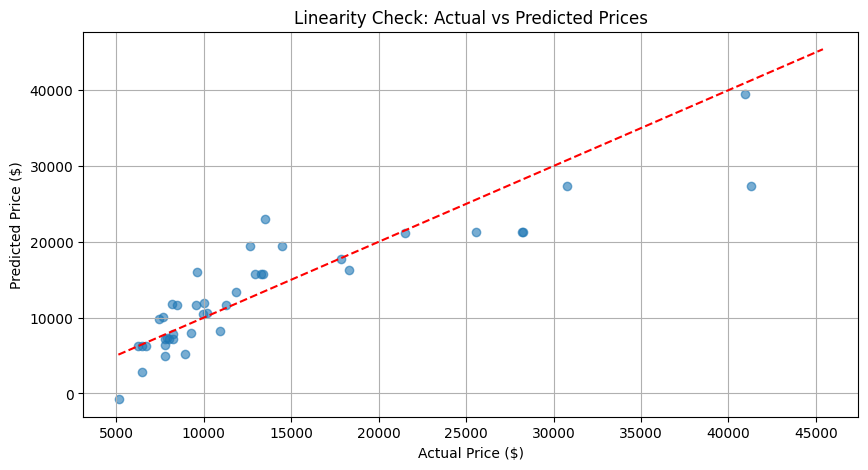

In [12]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test,y_pred,alpha=0.6)
plt.plot([y.min(),y.max()],[y.min(),y.max()],'r--')
plt.title("Linearity Check: Actual vs Predicted Prices")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.grid(True)
plt.show()
